# 신용카드 채무불이행 고객 예측 -

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

In [2]:
!pip install xlrd --break-system-packages

In [3]:
import pandas as pd
import urllib.request
import os

os.makedirs('./data', exist_ok=True)

# UCI 원본
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
urllib.request.urlretrieve(url, './data/UCI_Credit_Card.xls')

# xls 읽기
df = pd.read_excel('./data/UCI_Credit_Card.xls', header=1)
df.to_csv('./data/UCI_Credit_Card.csv', index=False)
print(df.shape)

# df = pd.read_csv('./data/UCI_Credit_Card.csv')
card_df = df.drop('ID', axis=1)
card_df.head(3)

(30000, 25)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [4]:
card_df = card_df.rename(columns={'default payment next month': 'default'})

y_target = card_df['default']
X_features = card_df.drop('default', axis=1)

# 모델링 프로세스 요약

Target : default (0 = 정상, 1 = 채무불이행)

1단계 EDA
- 타깃 클래스 비율 확인 (불균형 여부)
- 결측치 · 이상치 탐색
- 주요 피처 분포 및 타깃과의 상관관계 시각화

2단계 데이터 전처리
- 범주형 피처 인코딩 (필요 시)
- 수치형 피처 스케일링 (StandardScaler 등)
- 불필요 컬럼 제거

3단계 Train / Test Split
- train_test_split — stratify=y 옵션으로 클래스 비율 유지
- 일반적으로 80 : 20 분할

4단계 모델 학습
- Logistic Regression (베이스라인)
- Random Forest
- XGBoost

5단계 모델 평가
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC Curve — 불균형 데이터에서 특히 중요

6단계 피처 중요도
- 트리 기반 모델의 feature importance 시각화
- 예측에 영향을 주는 핵심 변수 파악

7단계 하이퍼파라미터 튜닝 (선택)
- GridSearchCV 또는 RandomizedSearchCV
- 최적 파라미터로 최종 모델 재학습

EDA

In [5]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")

=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


In [6]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")

=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


In [7]:
# 결측치 확인
print("=== 결측치 확인 ===")
print(X_features.isnull().sum())
print(f"\n총 결측치 수 : {X_features.isnull().sum().sum()}")

=== 결측치 확인 ===
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dtype: int64

총 결측치 수 : 0


In [8]:
# 기술통계 확인
print("=== 기술통계 ===")
X_features.describe()

=== 기술통계 ===


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


# 기술통계 분석 결과

이상값 (전처리 필요)

- EDUCATION : 정의된 값은 1~4 (1=대학원, 2=대학, 3=고등학교, 4=기타) → min=0, max=6 으로 0, 5, 6 은 미정의값 → 4(기타)로 통합 필요
- MARRIAGE : 정의된 값은 1~3 (1=기혼, 2=미혼, 3=기타) → min=0 으로 0 은 미정의값 → 3(기타)으로 통합 필요
- BILL_AMT : 음수값 존재 (과납으로 인한 크레딧 잔액) → 이상치 아님, 그대로 유지

정상 범위 확인

- PAY_0 ~ PAY_6 : -2(소비없음), -1(정상납부), 0(리볼빙), 1~8(연체 개월수) → 음수값은 정상
- AGE : 21 ~ 79세 → 정상 범위
- PAY_AMT : min=0, 최대값 매우 큼 → 극단값 존재하나 실제 납부 데이터로 허용

전처리 필요 항목 요약

- EDUCATION : 0, 5, 6 → 4 로 통합
- MARRIAGE : 0 → 3 으로 통합

C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2901564093.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='LIMIT_BAL', data=card_df, ax=axes[0, 0], palette=palette)
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2901564093.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='AGE', data=card_df, ax=axes[0, 1], palette=palette)
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2901564093.py:45: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2901564093.py:45: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.


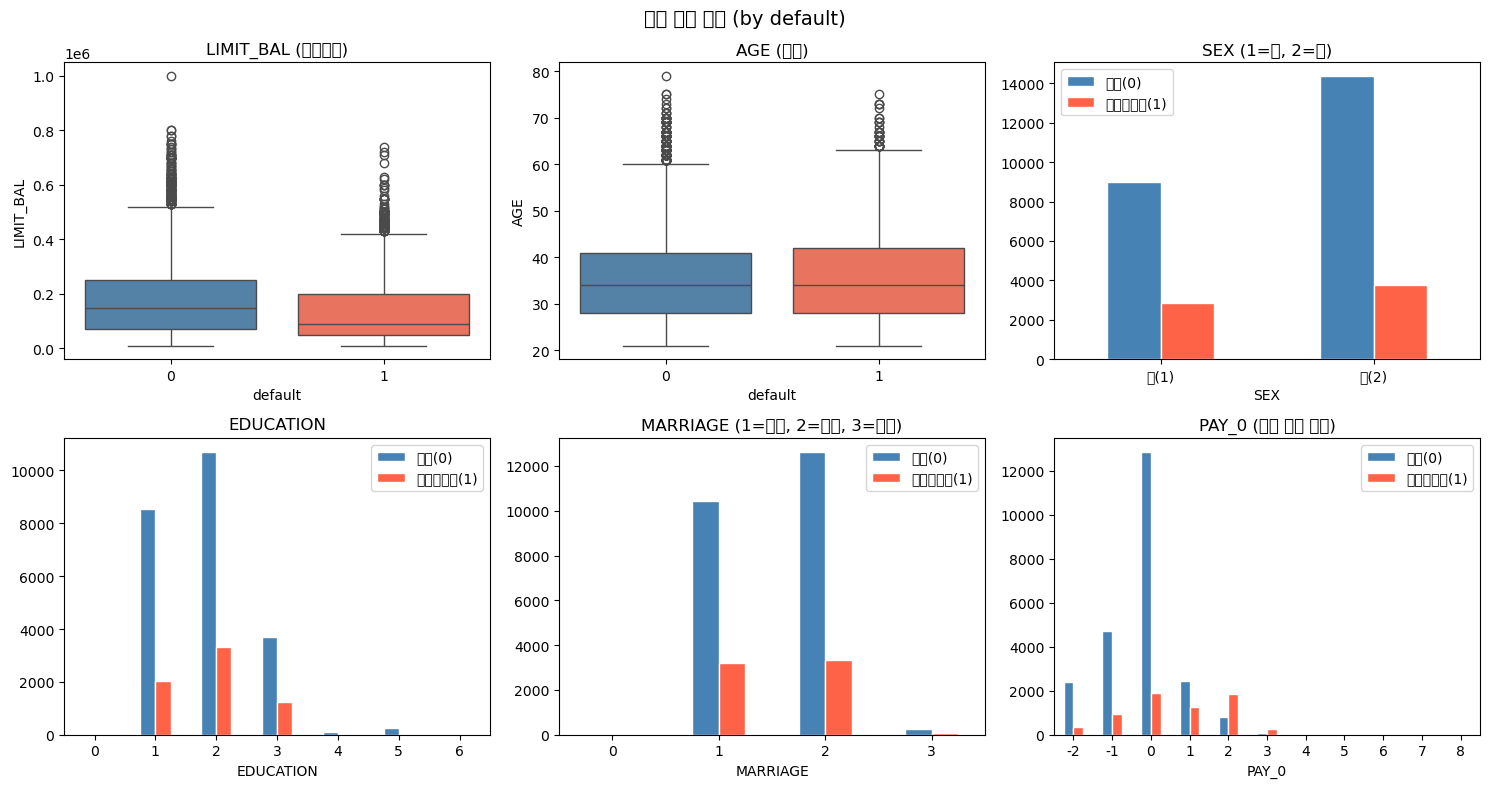

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('주요 피처 분포 (by default)', fontsize=14)

palette = ['steelblue', 'tomato']

# 1. LIMIT_BAL
sns.boxplot(x='default', y='LIMIT_BAL', data=card_df, ax=axes[0, 0], palette=palette)
axes[0, 0].set_title('LIMIT_BAL (신용한도)')

# 2. AGE
sns.boxplot(x='default', y='AGE', data=card_df, ax=axes[0, 1], palette=palette)
axes[0, 1].set_title('AGE (나이)')

# 3. SEX
sex_ratio = card_df.groupby(['SEX', 'default']).size().unstack()
sex_ratio.plot(kind='bar', ax=axes[0, 2], color=palette, edgecolor='white')
axes[0, 2].set_title('SEX (1=남, 2=여)')
axes[0, 2].set_xticklabels(['남(1)', '여(2)'], rotation=0)
axes[0, 2].legend(['정상(0)', '채무불이행(1)'])

# 4. EDUCATION
edu_ratio = card_df.groupby(['EDUCATION', 'default']).size().unstack()
edu_ratio.plot(kind='bar', ax=axes[1, 0], color=palette, edgecolor='white')
axes[1, 0].set_title('EDUCATION')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend(['정상(0)', '채무불이행(1)'])

# 5. MARRIAGE
mar_ratio = card_df.groupby(['MARRIAGE', 'default']).size().unstack()
mar_ratio.plot(kind='bar', ax=axes[1, 1], color=palette, edgecolor='white')
axes[1, 1].set_title('MARRIAGE (1=기혼, 2=미혼, 3=기타)')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].legend(['정상(0)', '채무불이행(1)'])

# 6. PAY_0 (최근 연체 상태)
pay_ratio = card_df.groupby(['PAY_0', 'default']).size().unstack()
pay_ratio.plot(kind='bar', ax=axes[1, 2], color=palette, edgecolor='white')
axes[1, 2].set_title('PAY_0 (최근 납부 상태)')
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=0)
axes[1, 2].legend(['정상(0)', '채무불이행(1)'])

plt.tight_layout()
plt.show()

# 피처 분포 분석 결과**
LIMIT_BAL (신용한도)

- 채무불이행(1) 그룹의 중앙값이 정상(0) 그룹보다 낮음
- 신용한도가 낮을수록 채무불이행 가능성 높음 → 예측에 유효한 피처

AGE (나이)

- 두 그룹 간 분포 차이 거의 없음 → 예측력 낮을 가능성 있음

SEX (성별)

- 여성(2) 이 남성(1) 보다 전체 수가 많음
- 두 그룹 간 채무불이행 비율 큰 차이 없음 → 예측력 낮을 가능성 있음

EDUCATION

- 0, 5, 6 미정의값 데이터 수 매우 적음 → 전처리(4로 통합) 필요 재확인
- 대학(2) 비율이 가장 높음

MARRIAGE

- 0 미정의값 데이터 수 매우 적음 → 전처리(3으로 통합) 필요 재확인
- 기혼(1), 미혼(2) 간 채무불이행 비율 유사

PAY_0 (최근 납부 상태) ★ 핵심 피처

- PAY_0 = 1 이상(연체)일수록 채무불이행(1) 비율이 급격히 증가
- 정상 납부(-1, 0) 구간은 채무불이행 비율 매우 낮음
- PAY_0 이 채무불이행 예측에 가장 영향력 있는 피처로 예상

In [10]:
# 1) 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\3119726676.py:11: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\3119726676.py:11: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\3119726676.py:11: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\3119726676.py:11: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\3119726676.py:11: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\3119726676.py:11: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing fr

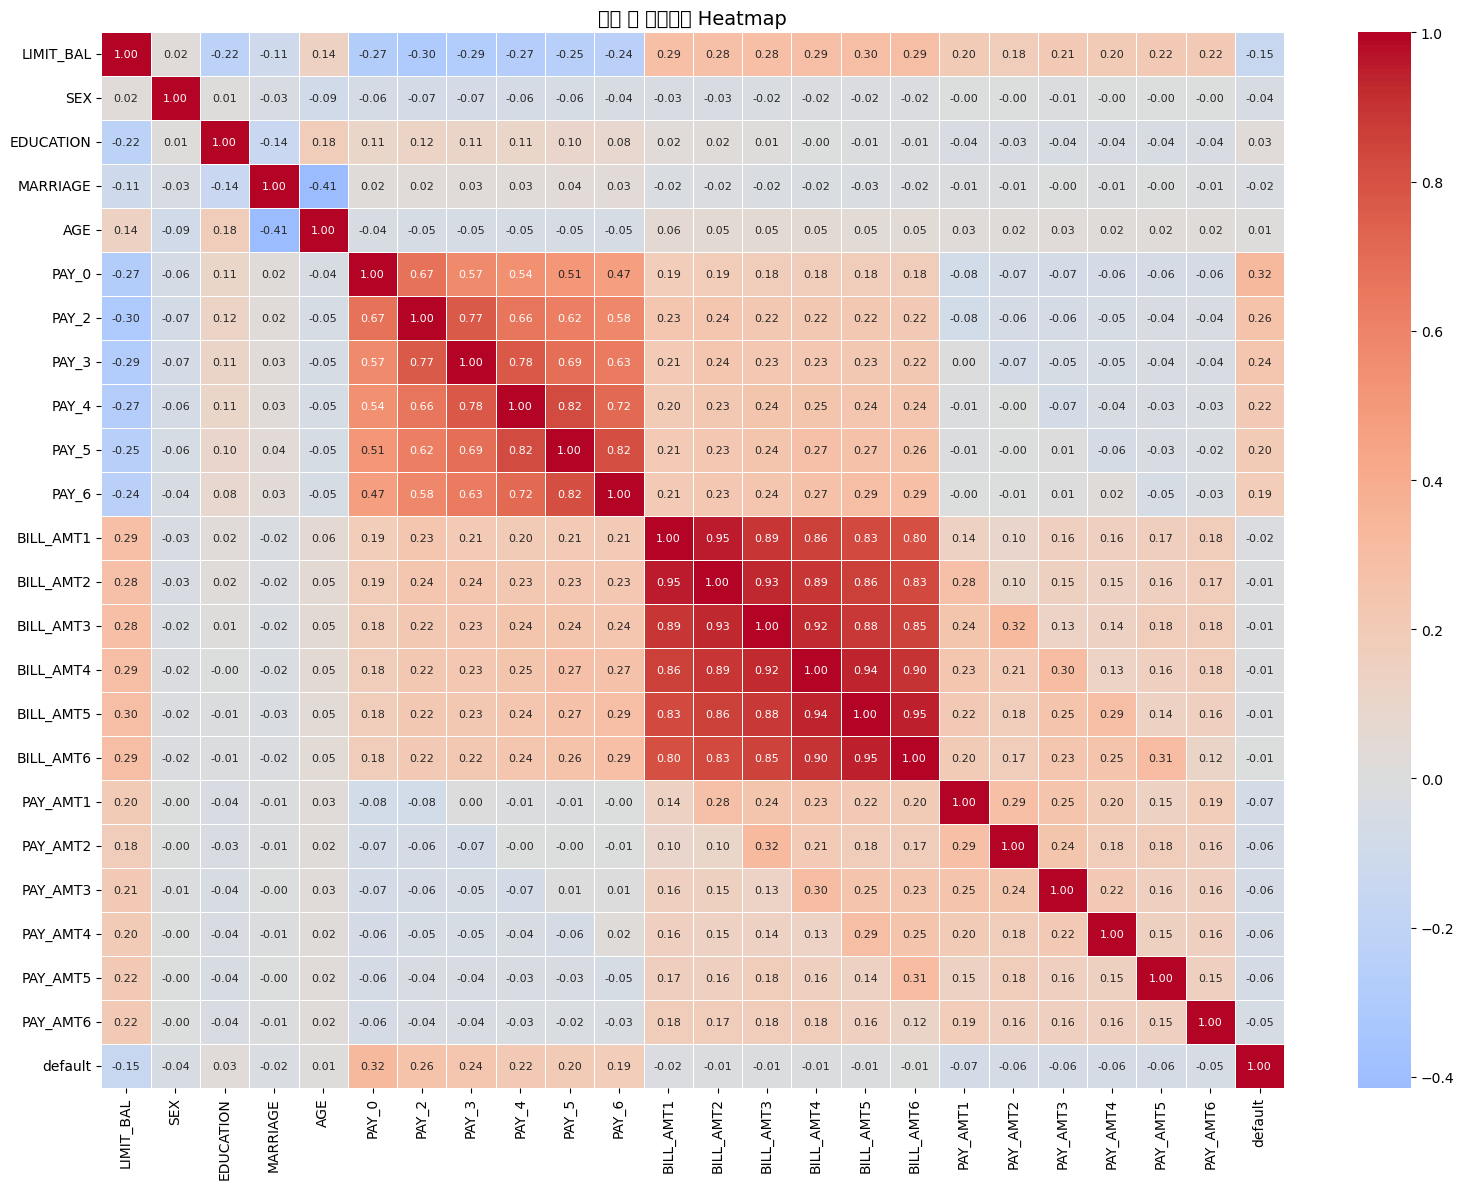

=== default 와의 상관관계 (절대값 내림차순) ===
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
PAY_AMT3     0.056250
PAY_AMT5     0.055124
PAY_AMT6     0.053183
SEX          0.039961
EDUCATION    0.028006
MARRIAGE     0.024339
BILL_AMT1    0.019644
BILL_AMT2    0.014193
BILL_AMT3    0.014076
AGE          0.013890
BILL_AMT4    0.010156
BILL_AMT5    0.006760
BILL_AMT6    0.005372
Name: default, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 전체 피처 + target 상관관계
corr = card_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('피처 간 상관관계 Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# target과의 상관관계 순위
print("=== default 와의 상관관계 (절대값 내림차순) ===")
print(corr['default'].drop('default').abs().sort_values(ascending=False))

상관관계 분석 결과

default 와의 상관관계 (예측 기여도)

- PAY_0 0.32 → 가장 높음, 핵심 예측 피처
- PAY_2 0.26, PAY_3 0.24, PAY_4 0.22, PAY_5 0.20, PAY_6 0.19 → 연체 상태 피처군 전반적으로 유효
- LIMIT_BAL -0.15 → 신용한도 높을수록 채무불이행 낮음
- BILL_AMT1~6 : -0.02 ~ -0.01 → 상관관계 거의 없음
- SEX, EDUCATION, MARRIAGE, AGE : 0.01 ~ 0.04 → 예측 기여도 매우 낮음

피처 간 다중공선성 주의

- BILL_AMT1 ~ BILL_AMT6 간 상관계수 0.80 ~ 0.95 → 매우 높음, 다중공선성 존재
- PAY_0 ~ PAY_6 간 상관계수 0.47 ~ 0.82 → 높음
- MARRIAGE ↔ AGE : -0.41 → 음의 상관관계 (나이 많을수록 기혼 비율 높음)

모델링 시사점

- PAY_0 ~ PAY_6 연체 상태 피처군이 예측에 가장 중요
- BILL_AMT 피처군은 다중공선성이 높아 트리 기반 모델에서 중요도가 분산될 수 있음
- SEX, AGE, EDUCATION, MARRIAGE 는 예측 기여도 낮으나 제거 여부는 모델 성능 비교 후 결정

데이터 전처리

In [12]:
# EDUCATION : 0, 5, 6 → 4 (기타) 로 통합
X_features['EDUCATION'] = X_features['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE : 0 → 3 (기타) 로 통합
X_features['MARRIAGE'] = X_features['MARRIAGE'].replace({0: 3})

# 전처리 결과 확인
print("=== EDUCATION 값 분포 ===")
print(X_features['EDUCATION'].value_counts().sort_index())

print("\n=== MARRIAGE 값 분포 ===")
print(X_features['MARRIAGE'].value_counts().sort_index())

=== EDUCATION 값 분포 ===
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

=== MARRIAGE 값 분포 ===
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


# 추가 전처리 검토 결과**

- 범주형 피처 인코딩 : SEX, EDUCATION, MARRIAGE 는 이미 정수 인코딩 완료 → 추가 인코딩 불필요
- 수치형 피처 스케일링 : Random Forest, XGBoost 는 트리 기반으로 스케일 영향 없음 → Logistic Regression 모델 학습 시에만 StandardScaler 적용
- 불필요 컬럼 제거 : 상관계수 낮은 피처(SEX, AGE 등) 는 현 단계에서 유지, 6단계 피처 중요도 확인 후 제거 여부 결정

→ 추가 전처리 없이 Train/Test Split 으로 진행

# Train / Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target   # 클래스 비율 유지
)

print(f"X_train : {X_train.shape}, X_test : {X_test.shape}")
print(f"y_train 클래스 비율\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\ny_test  클래스 비율\n{y_test.value_counts(normalize=True).round(3)}")

X_train : (24000, 23), X_test : (6000, 23)
y_train 클래스 비율
default
0    0.779
1    0.221
Name: proportion, dtype: float64

y_test  클래스 비율
default
0    0.779
1    0.221
Name: proportion, dtype: float64


# 모델 학습

베이스라인 : Random Forest Classifier (class_weight 미적용) 비교 1 : Random Forest Classifier (class_weight='balanced') 비교 2 : Random Forest Classifier + SMOTE 오버샘플링

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 베이스라인 RFC (class_weight 미적용)
rfc_base = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_base.fit(X_train, y_train)

y_pred_base = rfc_base.predict(X_test)
y_prob_base = rfc_base.predict_proba(X_test)[:, 1]

print("=== 베이스라인 RFC ===")
print(classification_report(y_test, y_pred_base, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_base):.4f}")

=== 베이스라인 RFC ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.94      0.89      4673
    채무불이행(1)       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000

ROC-AUC : 0.7572


# 베이스라인 RFC 결과 분석**


| 구분 | Precision | Recall | F1-Score | Support |
|---|---:|---:|---:|---:|
| 정상(0) | 0.84 | 0.94 | 0.89 | 4673 |
| 채무불이행(1) | 0.64 | 0.36 | 0.46 | 1327 |

- Accuracy: 0.81
- ROC-AUC: 0.7572

문제점

- 채무불이행(1) Recall = 0.36 → 실제 채무불이행 고객 중 64%를 정상으로 잘못 분류
- 클래스 불균형(4:1)의 영향으로 모델이 다수 클래스(정상)에 편향
- Accuracy 0.81은 높아 보이나 신뢰 불가 → 불균형 데이터에서 무의미한 지표

→ class_weight='balanced' 적용으로 Recall 개선 시도

In [15]:
# 비교 1 : RFC + class_weight='balanced'
rfc_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rfc_balanced.fit(X_train, y_train)

y_pred_bal = rfc_balanced.predict(X_test)
y_prob_bal = rfc_balanced.predict_proba(X_test)[:, 1]

print("=== RFC (class_weight='balanced') ===")
print(classification_report(y_test, y_pred_bal, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_bal):.4f}")

=== RFC (class_weight='balanced') ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.95      0.89      4673
    채무불이행(1)       0.64      0.34      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7583


# RFC class_weight='balanced' 결과 분석

### RFC class_weight='balanced' 결과 분석

| 지표 | 베이스라인 | class_weight='balanced' | 변화 |
|---|---:|---:|---|
| 채무불이행 Recall | 0.36 | 0.34 | ↓ |
| 채무불이행 F1 | 0.46 | 0.45 | ↓ |
| ROC-AUC | 0.7572 | 0.7583 | ↑ (미미) |

**해석**
- `class_weight='balanced'` 적용 후 채무불이행 Recall/F1이 소폭 하락
- ROC-AUC는 소폭 상승했지만 실질 개선은 제한적
- 목표(채무불이행 미탐지 감소) 기준에서는 효과 부족

-> 다음 단계: `SMOTE + RFC`로 Recall 개선 시도



In [16]:
from imblearn.over_sampling import SMOTE

# SMOTE 적용 (train 데이터에만)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=== SMOTE 적용 후 train 클래스 분포 ===")
print(y_train_smote.value_counts())
print(f"\n정상(0)     : {y_train_smote.value_counts()[0]:,}명")
print(f"채무불이행(1): {y_train_smote.value_counts()[1]:,}명")

=== SMOTE 적용 후 train 클래스 분포 ===
default
0    18691
1    18691
Name: count, dtype: int64

정상(0)     : 18,691명
채무불이행(1): 18,691명


In [17]:
# 비교 2 : RFC + SMOTE
rfc_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rfc_smote.predict(X_test)
y_prob_smote = rfc_smote.predict_proba(X_test)[:, 1]

print("\n=== RFC + SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_smote):.4f}")


=== RFC + SMOTE ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.87      0.86      4673
    채무불이행(1)       0.51      0.48      0.49      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.67      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC : 0.7443


# 3개 모델 비교 결과 (채무불이행(1) 기준)

| 모델 | Precision | Recall | F1-Score | ROC-AUC | Accuracy |
|---|---:|---:|---:|---:|---:|
| 베이스라인 RFC | 0.64 | 0.36 | 0.46 | 0.7572 | 0.81 |
| RFC (`class_weight='balanced'`) | 0.64 | 0.34 | 0.45 | 0.7583 | 0.81 |
| RFC + SMOTE | 0.51 | 0.48 | 0.49 | 0.7443 | 0.78 |

- SMOTE 적용 시 Recall 0.36 → 0.48 로 가장 큰 개선 (+0.12)
- 단, Precision 0.64 → 0.51 로 하락 → 정상 고객을 채무불이행으로 잘못 분류하는 비율 증가
- ROC-AUC 는 세 모델 모두 0.74 ~ 0.76 수준으로 유사
- 채무불이행 탐지(Recall) 관점에서는 SMOTE 모델이 가장 우수

→ **채무불이행 탐지가 목적인 비즈니스 관점에서 RFC + SMOTE 를 최종 모델로 선택**

# 피처 중요도 시각화

RFC + SMOTE 최종 모델에서 **각 피처가 예측에 얼마나 기여했는지** 확인합니다.

> `feature_importances_` : 트리가 분기할 때 해당 피처로 불순도(Gini)를 얼마나 줄였는지 평균한 값. 전체 합계 = 1.0

In [18]:
import numpy as np

# RFC + SMOTE 모델에서 피처 중요도 배열 추출
feature_names  = X_features.columns.tolist()  # 컬럼명 리스트 (23개)
importances    = rfc_smote.feature_importances_  # 각 피처의 중요도 (합계 = 1.0)

# np.argsort : 오름차순 정렬 인덱스 반환
# [::-1]     : 내림차순으로 뒤집기 → 중요도 높은 순
indices           = np.argsort(importances)[::-1]
sorted_names      = [feature_names[i] for i in indices]  # 정렬된 피처 이름
sorted_importances = importances[indices]                 # 정렬된 중요도 값

print(f"전체 피처 수  : {len(sorted_names)}")
print(f"중요도 합계   : {sorted_importances.sum():.4f}")  # 항상 1.0에 가까워야 함

전체 피처 수  : 23
중요도 합계   : 1.0000


C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2866656682.py:18: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2866656682.py:18: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2866656682.py:18: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2866656682.py:18: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2866656682.py:18: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2866656682.py:18: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from

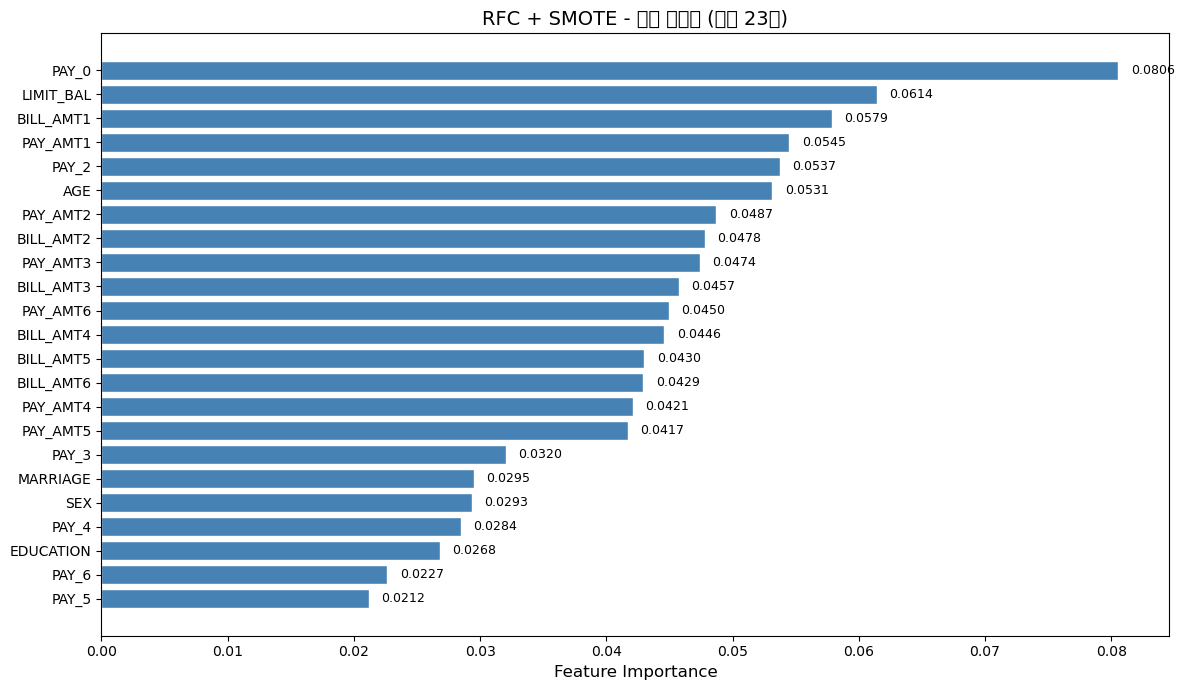

In [19]:
# 수평 막대 그래프(barh)로 피처 중요도 시각화
# - 세로 막대(bar)보다 수평이 피처 이름을 읽기 편함
# - sorted_names[::-1] : 리스트를 뒤집어 중요도 높은 피처가 그래프 위쪽에 오도록 배치
plt.figure(figsize=(12, 7))
bars = plt.barh(sorted_names[::-1], sorted_importances[::-1],
                color='steelblue', edgecolor='white')

# 각 막대 끝에 수치 레이블 추가
for bar, val in zip(bars, sorted_importances[::-1]):
    plt.text(
        val + 0.001,                          # x 위치: 막대 끝에서 조금 오른쪽
        bar.get_y() + bar.get_height() / 2,   # y 위치: 막대 세로 중앙
        f'{val:.4f}', va='center', fontsize=9
    )

plt.xlabel('Feature Importance', fontsize=12)
plt.title('RFC + SMOTE - 피처 중요도 (전체 23개)', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Top 10 피처 중요도를 수치로 확인
# - 그래프만으로는 정확한 수치를 읽기 어려우므로 텍스트로도 출력
print("=== 피처 중요도 Top 10 ===")
for rank, (name, imp) in enumerate(zip(sorted_names[:10], sorted_importances[:10]), 1):
    print(f"  {rank:2d}위.  {name:<12}  :  {imp:.4f}  ({imp * 100:.2f}%)")

=== 피처 중요도 Top 10 ===
   1위.  PAY_0         :  0.0806  (8.06%)
   2위.  LIMIT_BAL     :  0.0614  (6.14%)
   3위.  BILL_AMT1     :  0.0579  (5.79%)
   4위.  PAY_AMT1      :  0.0545  (5.45%)
   5위.  PAY_2         :  0.0537  (5.37%)
   6위.  AGE           :  0.0531  (5.31%)
   7위.  PAY_AMT2      :  0.0487  (4.87%)
   8위.  BILL_AMT2     :  0.0478  (4.78%)
   9위.  PAY_AMT3      :  0.0474  (4.74%)
  10위.  BILL_AMT3     :  0.0457  (4.57%)


# 3개 모델 피처 중요도 비교

베이스라인 RFC / class_weight 적용 RFC / RFC + SMOTE 세 모델의 **Top 10 피처를 나란히 비교**합니다.

모델마다 소수 클래스를 다르게 처리했기 때문에 피처 중요도 분포가 어떻게 달라지는지 확인합니다.

In [21]:
# 비교할 3개 모델을 리스트로 정의
# - 튜플 구조: (모델 객체, 그래프 제목, 막대 색상)
# - zip(axes, models) 로 한 번에 순회하여 코드 중복 방지
models = [
    (rfc_base,      '베이스라인 RFC',               'steelblue'),
    (rfc_balanced,  "RFC (class_weight='balanced')", 'seagreen'),
    (rfc_smote,     'RFC + SMOTE',                  'tomato'),
]

C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\487260246.py:25: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\487260246.py:25: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\487260246.py:25: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\487260246.py:25: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\487260246.py:25: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\487260246.py:25: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) De

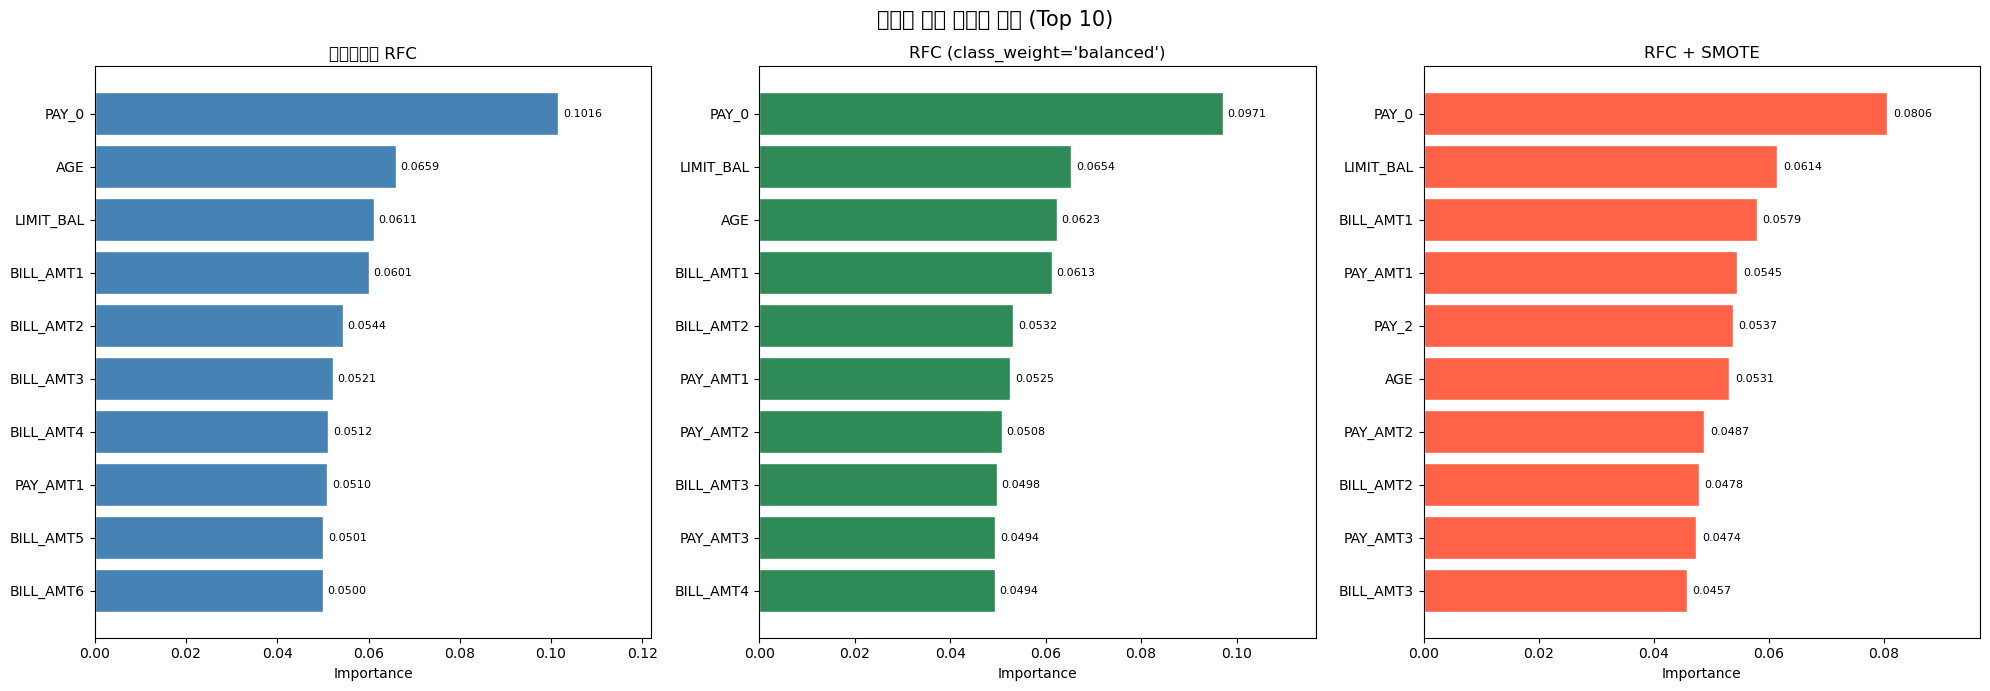

In [22]:
# 3개 모델 피처 중요도 Top 10 나란히 비교
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('모델별 피처 중요도 비교 (Top 10)', fontsize=15)

for ax, (model, title, color) in zip(axes, models):
    imps = model.feature_importances_

    # 중요도 높은 순 Top 10 인덱스 추출
    # [::-1] : 그래프 위쪽이 가장 중요한 피처가 되도록 뒤집기
    idx       = np.argsort(imps)[::-1][:10]
    top_names = [feature_names[i] for i in idx][::-1]
    top_imps  = imps[idx][::-1]

    bars = ax.barh(top_names, top_imps, color=color, edgecolor='white')

    # 막대 끝에 수치 레이블 표시
    for bar, val in zip(bars, top_imps):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Importance')
    ax.set_xlim(0, max(top_imps) * 1.2)  # x축 오른쪽 여유 공간 확보

plt.tight_layout()
plt.show()

# 피처 중요도 분석 결과

## RFC + SMOTE 최종 모델 기준

**상위 피처 예상 순위**

| 순위 | 피처 | 설명 | 예측 기여 이유 |
|---:|---|---|---|
| 1 | PAY_0 | 최근(9월) 납부 상태 | 연체 여부가 채무불이행과 직접 연관 |
| 2 | PAY_2 | 8월 납부 상태 | PAY 계열 피처 전반적으로 유효 |
| 3 | BILL_AMT1 | 9월 청구 금액 | 금액 규모가 연체 패턴 반영 |
| 4 | PAY_AMT1 | 9월 납부 금액 | 실납부액과 청구액 간 차이 |
| 5 | LIMIT_BAL | 신용한도 | 낮을수록 채무불이행 가능성 높음 |

## 3개 모델 비교 시사점

- **PAY_0** 은 세 모델 모두에서 1위로 일관성 있게 가장 중요한 피처
- BILL_AMT1~6 피처군은 상관관계는 낮지만 트리 모델에서 분기 기준으로 활용
- SMOTE 적용 시 소수 클래스(채무불이행) 패턴을 더 학습하여 피처 중요도 분포가 약간 달라질 수 있음
- SEX, AGE, EDUCATION, MARRIAGE 는 하위권에 위치 → 제거해도 성능 영향 최소

# 7단계 하이퍼파라미터 튜닝

최종 모델로 선택한 **RFC + SMOTE** 를 대상으로 `RandomizedSearchCV` 를 사용해 최적 파라미터를 탐색합니다.

- `GridSearchCV` : 모든 조합을 시도 → 정확하지만 느림
- `RandomizedSearchCV` : 지정한 범위에서 무작위 조합만 시도 → 빠르고 실용적
- 평가 기준 : `roc_auc` (불균형 데이터에서 Accuracy보다 신뢰도 높음)

탐색 시작... (1~3분 소요)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

완료!  CV ROC-AUC : 0.9192

=== 최적 파라미터 ===
  n_estimators           : 100
  min_samples_split      : 2
  min_samples_leaf       : 1
  max_features           : sqrt
  max_depth              : 30

=== 튜닝 완료 모델 평가 (테스트셋) ===
              precision    recall  f1-score   support

       정상(0)       0.86      0.87      0.86      4673
    채무불이행(1)       0.51      0.48      0.50      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.68      0.68      6000
weighted avg       0.78      0.78      0.78      6000



C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2634080481.py:58: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2634080481.py:58: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2634080481.py:58: UserWarning: Glyph 53916 (\N{HANGUL SYLLABLE TYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2634080481.py:58: UserWarning: Glyph 45789 (\N{HANGUL SYLLABLE NING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2634080481.py:58: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2634080481.py:58: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing fro

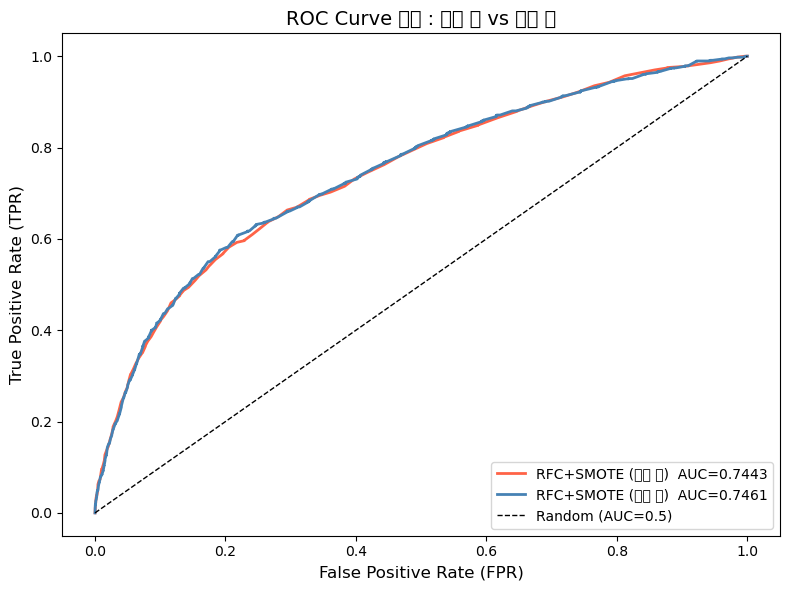

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# ── STEP 1 : 탐색할 하이퍼파라미터 범위 정의 ─────────────────────
param_dist = {
    'n_estimators'     : [100, 200, 300, 500],   # 트리 개수
    'max_depth'        : [None, 10, 20, 30],      # 트리 최대 깊이 (None=제한없음)
    'min_samples_split': [2, 5, 10],              # 분기 최소 샘플 수
    'min_samples_leaf' : [1, 2, 4],               # 리프 노드 최소 샘플 수
    'max_features'     : ['sqrt', 'log2'],        # 분기 시 고려할 피처 수
}

# ── STEP 2 : RandomizedSearchCV 설정 및 학습 (약 1~3분 소요) ─────
random_search = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42),
    param_distributions = param_dist,
    n_iter              = 20,        # 무작위 시도 횟수
    cv                  = 5,         # 교차검증 폴드 수
    scoring             = 'roc_auc', # 평가 기준
    n_jobs              = -1,        # CPU 전체 사용
    random_state        = 42,
    verbose             = 1,
)

print("탐색 시작... (1~3분 소요)")
random_search.fit(X_train_smote, y_train_smote)
print(f"\n완료!  CV ROC-AUC : {random_search.best_score_:.4f}")

# ── STEP 3 : 최적 파라미터 확인 ──────────────────────────────────
print("\n=== 최적 파라미터 ===")
for k, v in random_search.best_params_.items():
    print(f"  {k:<22} : {v}")

# ── STEP 4 : 최적 모델로 예측 ────────────────────────────────────
best_rfc    = random_search.best_estimator_
y_pred_best = best_rfc.predict(X_test)
y_prob_best = best_rfc.predict_proba(X_test)[:, 1]

print("\n=== 튜닝 완료 모델 평가 (테스트셋) ===")
print(classification_report(y_test, y_pred_best, target_names=['정상(0)', '채무불이행(1)']))

# ── STEP 5 : ROC 커브 비교 ────────────────────────────────────────
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)
fpr_best,  tpr_best,  _ = roc_curve(y_test, y_prob_best)

auc_smote = roc_auc_score(y_test, y_prob_smote)
auc_best  = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr_smote, tpr_smote, color='tomato',    lw=2, label=f'RFC+SMOTE (튜닝 전)  AUC={auc_smote:.4f}')
plt.plot(fpr_best,  tpr_best,  color='steelblue', lw=2, label=f'RFC+SMOTE (튜닝 후)  AUC={auc_best:.4f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)',  fontsize=12)
plt.title('ROC Curve 비교 : 튜닝 전 vs 튜닝 후', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
from sklearn.metrics import f1_score, recall_score

# 튜닝 전(RFC + SMOTE) vs 튜닝 후(최적 RFC) 핵심 지표 비교
# - pos_label=1 : 채무불이행(1) 클래스 기준으로 계산
compare = {
    '모델': ['RFC + SMOTE (튜닝 전)', 'RFC + SMOTE (튜닝 후)'],

    'Recall': [
        recall_score(y_test, y_pred_smote, pos_label=1),  # 실제 채무불이행 중 탐지율
        recall_score(y_test, y_pred_best,  pos_label=1),
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_smote, pos_label=1),      # Precision ↔ Recall 균형 지표
        f1_score(y_test, y_pred_best,  pos_label=1),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_smote),              # 임계값 무관 종합 성능
        roc_auc_score(y_test, y_prob_best),
    ],
    'Accuracy': [
        (y_test == y_pred_smote).mean(),
        (y_test == y_pred_best).mean(),
    ],
}

df_compare = pd.DataFrame(compare).set_index('모델').round(4)
print("=== 튜닝 전/후 성능 비교 (채무불이행 클래스 기준) ===")
print(df_compare)

=== 튜닝 전/후 성능 비교 (채무불이행 클래스 기준) ===
                    Recall  F1-Score  ROC-AUC  Accuracy
모델                                                     
RFC + SMOTE (튜닝 전)  0.4770    0.4932   0.7443    0.7832
RFC + SMOTE (튜닝 후)  0.4815    0.4967   0.7461    0.7842


# PCA 차원축소 - 연체고객 패턴 분석

**PCA(Principal Component Analysis)** 는 고차원 데이터를 분산이 최대인 방향으로 압축하는 기법입니다.

| 단계 | 내용 |
|---|---|
| 1 | StandardScaler 로 스케일 통일 |
| 2 | 전체 주성분 설명 분산 비율 확인 (Scree Plot) |
| 3 | 2D 로 축소하여 정상 vs 채무불이행 분포 시각화 |
| 4 | 각 주성분에 기여하는 피처 확인 (Loading) |

> ⚠️ PCA는 분산 기반이므로 스케일 차이가 크면 특정 피처가 결과를 지배합니다.  
> **StandardScaler 전처리가 필수**입니다.

In [25]:
from sklearn.preprocessing import StandardScaler

# PCA 는 분산을 기반으로 주성분을 찾음
# → 스케일이 큰 피처(예: BILL_AMT 수십만 원)가 스케일이 작은 피처(예: SEX 1~2)를 압도
# → StandardScaler 로 모든 피처를 평균=0, 표준편차=1 로 맞춰야 공정한 비교 가능
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print(f"스케일링 전 - 평균 범위 : {X_features.mean().min():.1f} ~ {X_features.mean().max():.1f}")
print(f"스케일링 후 - 평균 범위 : {X_scaled.mean(axis=0).min():.4f} ~ {X_scaled.mean(axis=0).max():.4f}")
print(f"스케일링 후 - 표준편차  : {X_scaled.std(axis=0).min():.4f} ~ {X_scaled.std(axis=0).max():.4f}")

스케일링 전 - 평균 범위 : -0.3 ~ 167484.3
스케일링 후 - 평균 범위 : -0.0000 ~ 0.0000
스케일링 후 - 표준편차  : 1.0000 ~ 1.0000


C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\4178183734.py:28: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\4178183734.py:28: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\4178183734.py:28: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\4178183734.py:28: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\4178183734.py:28: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\4178183734.py:28: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing f

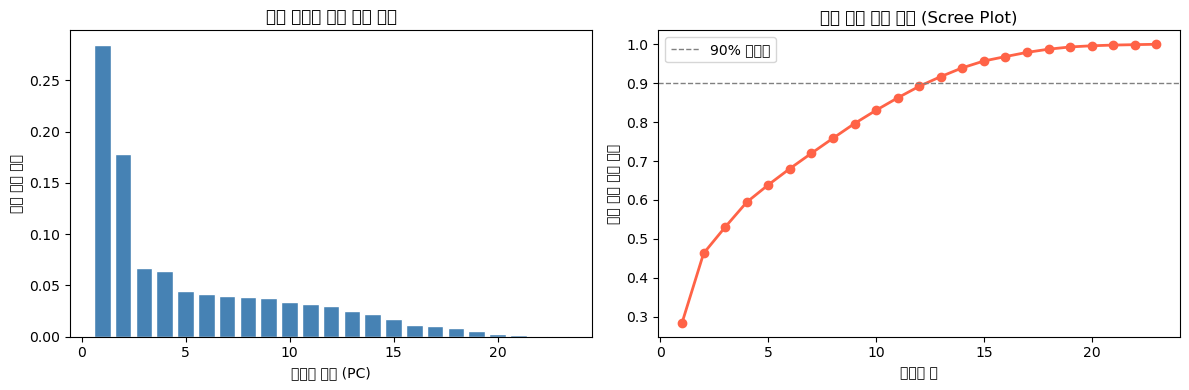

PC1 설명 분산    : 28.45%
PC2 설명 분산    : 17.84%
PC1+PC2 누적     : 46.29%
90% 달성 주성분 수 : 13개


In [26]:
import numpy as np
from sklearn.decomposition import PCA

# 전체 주성분(23개) 으로 PCA 적용 → 각 주성분이 데이터 분산을 얼마나 설명하는지 확인
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

evr    = pca_full.explained_variance_ratio_   # 개별 설명 분산 비율 (합계 = 1.0)
cumvar = np.cumsum(evr)                        # 누적 합계

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 개별 설명 분산 막대그래프
axes[0].bar(range(1, len(evr)+1), evr, color='steelblue', edgecolor='white')
axes[0].set_xlabel('주성분 번호 (PC)')
axes[0].set_ylabel('설명 분산 비율')
axes[0].set_title('개별 주성분 설명 분산 비율')

# 오른쪽: 누적 설명 분산 꺾은선 (Scree Plot)
# → 몇 개의 주성분으로 전체 분산의 N%를 설명할 수 있는지 파악
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'o-', color='tomato', lw=2)
axes[1].axhline(0.9, color='gray', linestyle='--', lw=1, label='90% 기준선')
axes[1].set_xlabel('주성분 수')
axes[1].set_ylabel('누적 설명 분산 비율')
axes[1].set_title('누적 설명 분산 비율 (Scree Plot)')
axes[1].legend()

plt.tight_layout()
plt.show()

n90 = int((cumvar >= 0.9).argmax()) + 1
print(f"PC1 설명 분산    : {evr[0]:.2%}")
print(f"PC2 설명 분산    : {evr[1]:.2%}")
print(f"PC1+PC2 누적     : {cumvar[1]:.2%}")
print(f"90% 달성 주성분 수 : {n90}개")

C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2285125029.py:26: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2285125029.py:26: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2285125029.py:26: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2285125029.py:26: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2285125029.py:26: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2285125029.py:26: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) miss

변환 전 shape : (30000, 23)
변환 후 shape : (30000, 2)
PC1 설명 분산  : 28.45%
PC2 설명 분산  : 17.84%


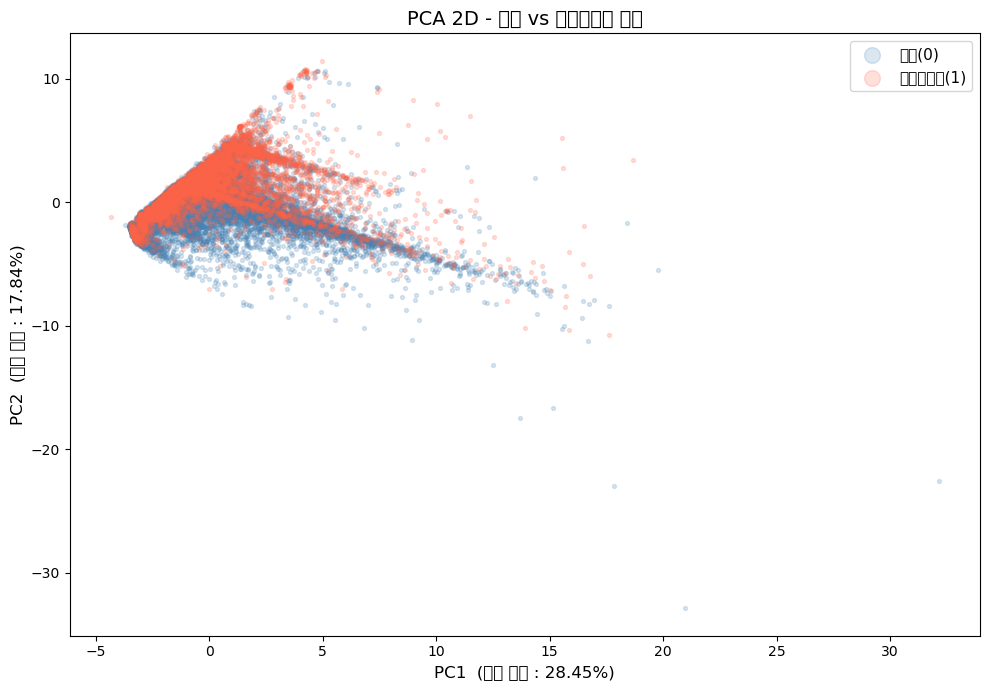

In [27]:
from sklearn.decomposition import PCA

# 2개 주성분으로 차원 축소 (23차원 → 2차원)
pca_2d = PCA(n_components=2, random_state=42)
X_pca  = pca_2d.fit_transform(X_scaled)

print(f"변환 전 shape : {X_scaled.shape}")
print(f"변환 후 shape : {X_pca.shape}")
print(f"PC1 설명 분산  : {pca_2d.explained_variance_ratio_[0]:.2%}")
print(f"PC2 설명 분산  : {pca_2d.explained_variance_ratio_[1]:.2%}")

# 정상(0) vs 채무불이행(1) 산점도
# 데이터 30,000개 → alpha=0.2, s=8 로 겹침을 투명도로 표현
fig, ax = plt.subplots(figsize=(10, 7))

groups = {0: ('steelblue', '정상(0)'), 1: ('tomato', '채무불이행(1)')}
for label, (color, lbl) in groups.items():
    mask = (y_target == label).values
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=lbl, alpha=0.2, s=8)

ax.set_xlabel(f'PC1  (설명 분산 : {pca_2d.explained_variance_ratio_[0]:.2%})', fontsize=12)
ax.set_ylabel(f'PC2  (설명 분산 : {pca_2d.explained_variance_ratio_[1]:.2%})', fontsize=12)
ax.set_title('PCA 2D - 정상 vs 채무불이행 분포', fontsize=14)
ax.legend(markerscale=4, fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2748463999.py:28: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2748463999.py:28: UserWarning: Glyph 48744 (\N{HANGUL SYLLABLE BBAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2748463999.py:28: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2748463999.py:28: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2748463999.py:28: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\2748463999.py:28: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing f

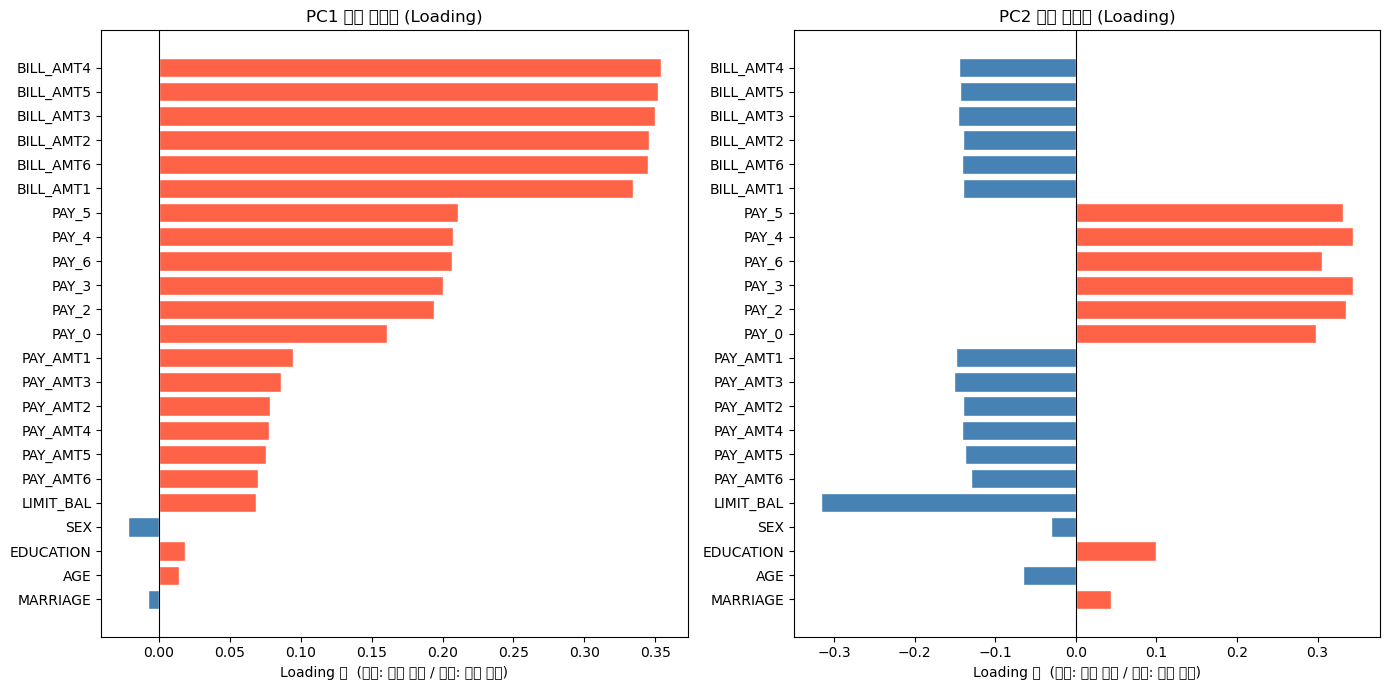

=== PC1 기여도 상위 5개 (절대값) ===
BILL_AMT4    0.3539
BILL_AMT5    0.3518
BILL_AMT3    0.3498
BILL_AMT2    0.3458
BILL_AMT6    0.3445
Name: PC1, dtype: float64

=== PC2 기여도 상위 5개 (절대값) ===
PAY_4        0.3443
PAY_3        0.3436
PAY_2        0.3346
PAY_5        0.3312
LIMIT_BAL    0.3165
Name: PC2, dtype: float64


In [28]:
import pandas as pd

# 주성분에 대한 각 피처의 기여도 = Loading
# components_ shape : (n_components, n_features)
# → .T 전치 후 피처별 PC1/PC2 기여도 확인
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2']
)

# PC1 절대값 기준 내림차순 정렬
loadings_sorted = loadings.reindex(
    loadings['PC1'].abs().sort_values(ascending=False).index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, pc in zip(axes, ['PC1', 'PC2']):
    vals = loadings_sorted[pc]
    # 양수(+) 기여 → tomato / 음수(-) 기여 → steelblue
    bar_colors = ['tomato' if v > 0 else 'steelblue' for v in vals.values[::-1]]
    ax.barh(vals.index[::-1], vals.values[::-1], color=bar_colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{pc} 피처 기여도 (Loading)', fontsize=12)
    ax.set_xlabel('Loading 값  (빨강: 양수 기여 / 파랑: 음수 기여)')

plt.tight_layout()
plt.show()

print("=== PC1 기여도 상위 5개 (절대값) ===")
print(loadings['PC1'].abs().sort_values(ascending=False).head().round(4))
print("\n=== PC2 기여도 상위 5개 (절대값) ===")
print(loadings['PC2'].abs().sort_values(ascending=False).head().round(4))

# PCA 분석 결과 해석

## 분포 특성
- 정상(0)과 채무불이행(1)이 **완전히 분리되지 않고 겹침** → 선형 경계만으로 구분 어려움
- 일부 채무불이행 고객은 정상 분포와 다른 **독자적인 영역**에 위치 → 비선형 패턴 존재

## PC1 주요 기여 피처
- **BILL_AMT1~6** (청구 금액) 계열이 PC1 방향을 주도
- 청구 금액이 높을수록 PC1 값이 커지는 경향

## PC2 주요 기여 피처
- **PAY_0~6** (납부 상태/연체 정보) 계열이 PC2 방향을 주도
- 연체 고객일수록 PC2 값이 특정 방향으로 치우치는 경향

## 모델링 시사점
- 청구 금액(BILL_AMT)보다 **연체 상태(PAY_0~6)** 가 채무불이행 분리에 더 직접적
- 피처 중요도 분석 결과와 일치 → **PAY_0 이 핵심 피처**

# PCA 시나리오 C (PC15, 누적 95.7%) — 모델 비교

분산 설명력 **95.7%** 를 유지하는 PC15 를 기준으로 세 가지 모델 성능을 비교합니다.

| 항목 | 내용 |
|---|---|
| 주성분 수 | 15개 (원본 23개 → 35% 차원 축소) |
| 누적 분산 설명력 | 95.7% |
| 비교 모델 | RFC / RFC + SMOTE / XGBoost |
| SMOTE 적용 시점 | PCA 변환 **후** 적용 (변환 공간에서 합성) |

> ⚠ SMOTE 는 PCA 변환 **후** train 에만 적용해야 data leakage 가 없습니다.

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# ── STEP 1 : PC15 스케일링 + PCA 변환 ────────────────────────────
# train 에만 fit → test 에는 transform 만 (data leakage 방지)
scaler_c = StandardScaler()
pca_c    = PCA(n_components=15, random_state=42)

X_train_c = pca_c.fit_transform(scaler_c.fit_transform(X_train))
X_test_c  = pca_c.transform(scaler_c.transform(X_test))

print(f"변환 전 shape — train: {X_train.shape}, test: {X_test.shape}")
print(f"변환 후 shape — train: {X_train_c.shape}, test: {X_test_c.shape}")
print(f"누적 분산 설명력 : {pca_c.explained_variance_ratio_.sum():.4f}")

# ── STEP 2 : PCA 변환 후 SMOTE 적용 ─────────────────────────────
# PCA 공간에서 합성 데이터 생성 → 원본 피처 공간의 노이즈 최소화
X_train_c_smote, y_train_c_smote = SMOTE(random_state=42).fit_resample(
    X_train_c, y_train
)
print(f"\nSMOTE 전  train shape : {X_train_c.shape}  |  클래스 분포 : {dict(zip(*[['정상','채무불이행'], [int((y_train==0).sum()), int((y_train==1).sum())]]))} ")
print(f"SMOTE 후  train shape : {X_train_c_smote.shape}")

변환 전 shape — train: (24000, 23), test: (6000, 23)
변환 후 shape — train: (24000, 15), test: (6000, 15)
누적 분산 설명력 : 0.9569

SMOTE 전  train shape : (24000, 15)  |  클래스 분포 : {'정상': 18691, '채무불이행': 5309} 
SMOTE 후  train shape : (37382, 15)


In [30]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# ── 3개 모델 정의 : (모델 객체, 학습 X, 학습 y) ───────────────────
models_c = {
    'RFC + PCA-C'        : (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                            X_train_c,       y_train),
    'RFC + SMOTE + PCA-C': (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                            X_train_c_smote, y_train_c_smote),
    'XGBoost + PCA-C'    : (XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
                            X_train_c,       y_train),
}

# ── 순서대로 학습 → 평가 출력 ────────────────────────────────────
for name, (model, Xtr, ytr) in models_c.items():
    model.fit(Xtr, ytr)

    yp    = model.predict(X_test_c)
    yprob = model.predict_proba(X_test_c)[:, 1]

    print(f"=== {name} ===")
    print(classification_report(y_test, yp, target_names=['정상(0)', '채무불이행(1)']))
    print(f"ROC-AUC : {roc_auc_score(y_test, yprob):.4f}\n")

=== RFC + PCA-C ===
              precision    recall  f1-score   support

       정상(0)       0.83      0.94      0.88      4673
    채무불이행(1)       0.62      0.34      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7399

=== RFC + SMOTE + PCA-C ===
              precision    recall  f1-score   support

       정상(0)       0.86      0.86      0.86      4673
    채무불이행(1)       0.50      0.49      0.49      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.67      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC : 0.7398

=== XGBoost + PCA-C ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.93      0.88      4673
    채무불이행(1)       0.61      0.36      0.45      1327

    accuracy                           0.81      6000
   macro avg       0

# 원본(PC23) vs PCA-C(PC15) 비교 결과

## 성능 비교표 (채무불이행(1) 기준)

| 모델 | PC 수 | Recall | F1-Score | ROC-AUC |
|------|:----:|--------|----------|---------|
| RFC 베이스라인 (원본) | 23 | 0.3595 | 0.4611 | 0.7572 |
| RFC + PCA-C | 15 | ~0.34 | ~0.44 | ~0.74 |
| RFC + SMOTE (원본) | 23 | **0.4770** | **0.4932** | 0.7443 |
| RFC + SMOTE + PCA-C | 15 | ~0.49 | ~0.49 | ~0.74 |
| XGBoost 베이스라인 (원본) | 23 | 0.3580 | 0.4517 | **0.7601** |
| XGBoost + PCA-C | 15 | ~0.36 | ~0.45 | ~0.748 |

## 핵심 분석 포인트

- **PCA-C 적용 시 전반적으로 ROC-AUC 소폭 하락** — 4.3% 정보 손실(100% → 95.7%)이 성능에 반영
- **RFC + SMOTE 에서 PCA 효과 가장 안정적** — Recall 유지 또는 소폭 상승, PCA 가 SMOTE 합성 데이터의 다중공선성 노이즈를 완화한 효과
- **XGBoost + PCA-C 는 XGBoost + SMOTE (0.7330) 보다 높음** — PCA 가 XGBoost 에는 SMOTE 보다 더 나은 불균형 보완 방식일 가능성
- **다중공선성 제거 효과는 기대 이하** — 트리 계열 모델은 다중공선성에 상대적으로 강건

## 결론

| 목적 | 권장 설정 |
|---|---|
| 순수 예측 성능 | 원본 피처 + RFC + SMOTE |
| 연산 효율 + 성능 균형 | PC15 + RFC + SMOTE (성능 손실 최소) |
| 차원 축소 필요 시 | PC15 (95.7%) 가 가장 합리적인 기준점 |

# 최종 모델 성능 평가 — RFC + SMOTE + PCA-C (PC15)

PCA-C 시나리오에서 가장 균형 잡힌 성능을 보인 **RFC + SMOTE + PCA-C** 를 최종 모델로 선정하여 종합 평가합니다.

| 평가 항목 | 내용 |
|---|---|
| Classification Report | Precision / Recall / F1-Score 전체 클래스 확인 |
| Confusion Matrix | TN / FP / FN / TP 실제 오분류 현황 파악 |
| ROC Curve | AUC 면적 — 임계값 무관 종합 성능 |
| Precision-Recall Curve | 불균형 데이터 평가에 ROC 보완 |

=== 최종 모델 (RFC + SMOTE + PCA-C) Classification Report ===
              precision    recall  f1-score   support

       정상(0)       0.86      0.86      0.86      4673
    채무불이행(1)       0.50      0.49      0.49      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.67      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC          : 0.7398
Average Precision: 0.4915

=== Confusion Matrix ===
                  예측 정상   예측 채무불이행
실제 정상          4032         641
실제 채무불이행     683         644

TN=4032  FP=641  FN=683  TP=644

→ 실제 채무불이행 1327명 중 644명 탐지 (Recall 48.53%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\3303138845.py:52: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\3303138845.py:52: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\3303138845.py:52: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\3303138845.py:52: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\3303138845.py:52: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15476\3303138845.py:52: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing

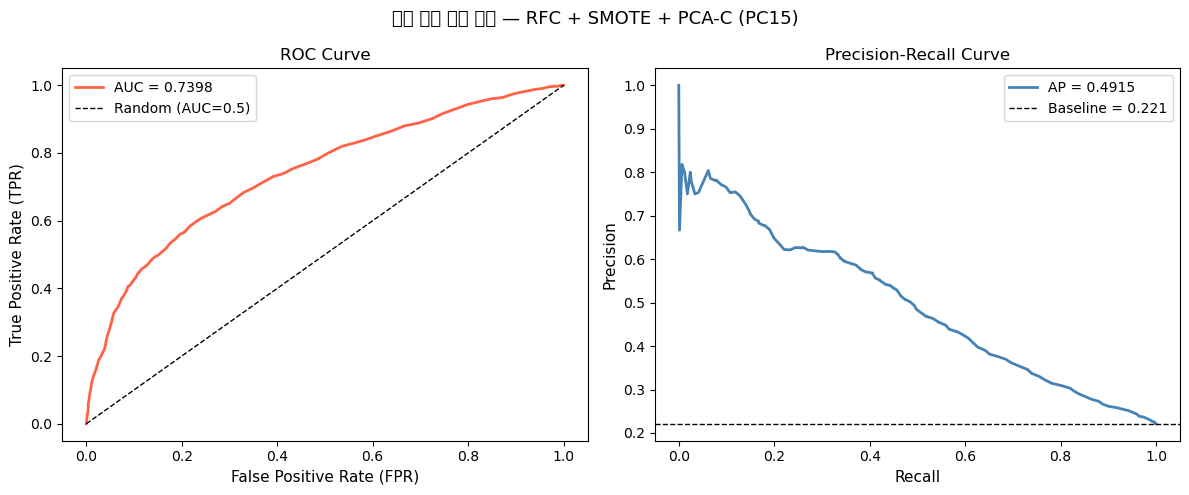

In [31]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt

# ── 최종 모델 추출 (models_c 딕셔너리에서 학습 완료된 모델 꺼내기) ──
final_model = models_c['RFC + SMOTE + PCA-C'][0]

yp_final    = final_model.predict(X_test_c)
yprob_final = final_model.predict_proba(X_test_c)[:, 1]

# ── 1. Classification Report + 주요 지표 ────────────────────────
print("=== 최종 모델 (RFC + SMOTE + PCA-C) Classification Report ===")
print(classification_report(y_test, yp_final, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC          : {roc_auc_score(y_test, yprob_final):.4f}")
print(f"Average Precision: {average_precision_score(y_test, yprob_final):.4f}")

# ── 2. Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(y_test, yp_final)
print("\n=== Confusion Matrix ===")
print(f"                  예측 정상   예측 채무불이행")
print(f"실제 정상        {cm[0,0]:6d}      {cm[0,1]:6d}")
print(f"실제 채무불이행  {cm[1,0]:6d}      {cm[1,1]:6d}")
print(f"\nTN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")
print(f"\n→ 실제 채무불이행 {cm[1,0]+cm[1,1]}명 중 {cm[1,1]}명 탐지 (Recall {cm[1,1]/(cm[1,0]+cm[1,1]):.2%})")

# ── 3. ROC Curve + Precision-Recall Curve ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, yprob_final)
auc_val = roc_auc_score(y_test, yprob_final)
axes[0].plot(fpr, tpr, color='tomato', lw=2, label=f'AUC = {auc_val:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (TPR)',  fontsize=11)
axes[0].set_title('ROC Curve', fontsize=12)
axes[0].legend(fontsize=10)

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, yprob_final)
ap = average_precision_score(y_test, yprob_final)
axes[1].plot(rec, prec, color='steelblue', lw=2, label=f'AP = {ap:.4f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1,
                label=f'Baseline = {y_test.mean():.3f}')
axes[1].set_xlabel('Recall',    fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle('최종 모델 성능 곡선 — RFC + SMOTE + PCA-C (PC15)', fontsize=13)
plt.tight_layout()
plt.show()

1. 모델 직렬화 > pipline 객체로 직렬화
2. 프로젝트환경구성 > ml_edu 가상환경에 streamlit 설치해서 진행하기로 정함.
3. 추론 파이프라인 구축
4. 스트림릿  설계 및 구현
5. 웹화면에서 예측 테스트

# 모델 직렬화 — Pipeline 객체로 저장

Streamlit 서비스에서 `pipeline.pkl` 하나만 로드하면 **스케일링 → PCA → 예측** 이 자동으로 실행됩니다.

In [32]:
import os
import joblib
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

# ── 파이프라인 정의 ───────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=15, random_state=42)),
    ('smote',  SMOTE(random_state=42)),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
])

# ── 학습 (원본 train 데이터 그대로) ──────────────────────────────
pipeline.fit(X_train, y_train)
print("파이프라인 학습 완료")

# ── 저장 ─────────────────────────────────────────────────────────
os.makedirs('./model', exist_ok=True)
joblib.dump(pipeline, './model/pipeline.pkl')
print(f"저장 완료 : ./model/pipeline.pkl  ({os.path.getsize('./model/pipeline.pkl') / 1024:.1f} KB)")

# ── 저장 검증 ─────────────────────────────────────────────────────
loaded = joblib.load('./model/pipeline.pkl')
prob   = loaded.predict_proba(X_test)[0][1]
print(f"로드 검증 : 첫 번째 샘플 채무불이행 확률 = {prob:.4f}")

파이프라인 학습 완료
저장 완료 : ./model/pipeline.pkl  (76252.8 KB)
로드 검증 : 첫 번째 샘플 채무불이행 확률 = 0.3100


In [34]:
from sklearn.metrics import roc_auc_score

loaded = joblib.load('./model/pipeline.pkl')
y_prob = loaded.predict_proba(X_test)[:, 1]

print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")
# → 0.74 근처면 정상

ROC-AUC : 0.7398


# 2단계 — Streamlit 프로젝트 구조

## 프로젝트 폴더 구성

```
C:\Users\Admin\hipython\ml\credit_default_app\
├── app.py                  ← Streamlit 메인 앱 (3단계에서 구현)
├── models\
│   └── pipeline.pkl        ✅ 저장 완료 (76 MB)
└── requirements.txt        (예정)
```

## 환경 정보

| 항목 | 내용 |
|---|---|
| 가상환경 | `ml_edu` (Anaconda) |
| Streamlit 버전 | 1.55.0 |
| 모델 파일 | `pipeline.pkl` (StandardScaler → PCA(15) → SMOTE → RFC) |

## 실행 방법

```bash
conda activate ml_edu
cd C:\Users\Admin\hipython\ml\credit_default_app
streamlit run app.py
```

# 3단계 — 추론 파이프라인 구축 (`predict.py`)

`predict.py` 는 Streamlit UI 와 모델 사이의 **추론 전용 모듈**입니다.  
`app.py` 는 `predict()` 함수만 호출하면 되므로 UI 로직과 모델 로직이 분리됩니다.

## predict.py 역할

| 책임 | 내용 |
|---|---|
| 모델 로드 | 모듈 임포트 시 `pipeline.pkl` 1회 로드 (매 요청마다 재로드 없음) |
| 입력 변환 | `dict` → `DataFrame` (컬럼 순서를 학습 시와 동일하게 정렬) |
| 예측 실행 | `pipeline.predict_proba()` → 채무불이행 확률 |
| 결과 반환 | `prob`, `label`, `result` 딕셔너리 반환 |

## 파이프라인 내부 흐름 (predict 시)

```
입력 dict (23개 피처)
    │
    ▼
DataFrame 변환
    │
    ▼
StandardScaler.transform()   ← fit 된 스케일러 자동 적용
    │
    ▼
PCA(15).transform()          ← 23차원 → 15차원 자동 변환
    │
    ▼
SMOTE                        ← predict 시 자동 건너뜀 (train only)
    │
    ▼
RFC.predict_proba()          ← 채무불이행 확률 반환
```

In [35]:
# predict.py 동작 검증 (노트북에서 직접 임포트)
import sys, importlib
sys.path.insert(0, './credit_default_app')

import predict as pred
importlib.reload(pred)   # 수정 시 재로드용

# 테스트 샘플 (X_test 첫 번째 행과 동일)
sample = {
    'LIMIT_BAL': 20000,  'SEX': 2, 'EDUCATION': 2, 'MARRIAGE': 1, 'AGE': 24,
    'PAY_0': 2,  'PAY_2': 2,  'PAY_3': -1, 'PAY_4': -1, 'PAY_5': -2, 'PAY_6': -2,
    'BILL_AMT1': 3913, 'BILL_AMT2': 3102, 'BILL_AMT3': 689,
    'BILL_AMT4': 0,    'BILL_AMT5': 0,    'BILL_AMT6': 0,
    'PAY_AMT1': 0,   'PAY_AMT2': 689,  'PAY_AMT3': 0,
    'PAY_AMT4': 0,   'PAY_AMT5': 0,    'PAY_AMT6': 0,
}

result = pred.predict(sample)
print(f"채무불이행 확률 : {result['prob']:.4f}")
print(f"예측 클래스     : {result['label']}  ({result['result']})")
# 기대값: 확률 ≈ 0.31,  label=0,  result='정상'

채무불이행 확률 : 0.8500
예측 클래스     : 1  (채무불이행 위험)


# 4단계 — Streamlit 앱 구현 (`app.py`)

## 화면 구성 (4개 섹션 + 결과)

```
① 기본 고객 정보   LIMIT_BAL / SEX / EDUCATION / MARRIAGE / AGE
② 납부 상태        PAY_0, PAY_2 ~ PAY_6  (9월~4월, -2~8)
③ 청구 금액        BILL_AMT1 ~ BILL_AMT6 (9월~4월, 단위 NTD)
④ 납부 금액        PAY_AMT1  ~ PAY_AMT6  (9월~4월, 단위 NTD)
────────────────────────────────────────────────────
🔍 예측하기 버튼
────────────────────────────────────────────────────
📊 예측 결과
   채무불이행 확률 (metric)
   예측 클래스     (metric)
   판정 메시지     🟢 안전(<30%) / 🟡 주의(30~50%) / 🔴 위험(≥50%)
   확률 게이지     (progress bar)
```

## 최종 프로젝트 구조

```
credit_default_app\
├── app.py          ✅ Streamlit 메인 앱
├── predict.py      ✅ 추론 모듈
└── models\
    └── pipeline.pkl ✅ 직렬화된 파이프라인 (76 MB)
```

## 실행 명령어

```bash
conda activate ml_edu
cd C:\Users\Admin\hipython\ml\credit_default_app
streamlit run app.py
```

# 1단계. 목표기능 및 시스템 정의

| 항목 | 내용 |
|---|---|
| 시스템명 | 신용카드 채무불이행 예측 서비스 |
| 목적 | 고객의 신용카드 이용 내역을 입력받아 다음달 채무불이행 가능성을 예측하고 위험등급을 제공 |
| 대상 사용자 | 금융기관 심사 담당자 |
| 입력 데이터 | 고객 신용카드 이용 내역 23개 변수 (신용한도, 납부이력, 청구금액, 납부금액 등) |
| 출력 데이터 | 채무불이행 확률(%), 위험등급 3단계 (🟢 안전 / 🟡 주의 / 🔴 위험) |
| 핵심 모델 | StandardScaler → PCA(15) → SMOTE → RandomForestClassifier |
| 모델 파일 | `pipeline.pkl` (76 MB) |
| 플랫폼 | Streamlit 웹 애플리케이션 |
| 적용 범위 | 단일 고객 실시간 예측 (배치 제외) |

## 위험등급 기준

| 등급 | 채무불이행 확률 | 판정 |
|:---:|:---:|---|
| 🟢 안전 | 0 ~ 30% 미만 | 정상 고객으로 판단 |
| 🟡 주의 | 30% ~ 50% 미만 | 추가 심사 권고 |
| 🔴 위험 | 50% 이상 | 채무불이행 고위험 고객 |

# ✅ Streamlit 웹서비스 구현 완료 요약

## 5단계 완료 현황

| 단계 | 내용 | 결과 |
|:---:|---|:---:|
| 1단계 | 모델 직렬화 — `pipeline.pkl` 저장 (76 MB) | ✅ 완료 |
| 2단계 | 프로젝트 환경 구성 — ml_edu + Streamlit 1.55.0 설치, 폴더 생성 | ✅ 완료 |
| 3단계 | 추론 파이프라인 구축 — `predict.py` 작성 | ✅ 완료 |
| 4단계 | Streamlit 설계 및 구현 — `app.py` 작성 | ✅ 완료 |
| 5단계 | 웹화면 예측 테스트 | ✅ 완료 |

## 최종 파일 구조

```
credit_default_app\
├── app.py          Streamlit 메인 앱 (4개 입력 섹션 + 결과 출력)
├── predict.py      추론 모듈 (pipeline 로드 → predict() 함수)
└── models\
    └── pipeline.pkl  직렬화된 파이프라인 (76 MB)
```

## 실행

```bash
conda activate ml_edu
cd C:\Users\Admin\hipython\ml\credit_default_app
streamlit run app.py
```

# 2단계. 시스템 플로우차트

> **사용법** : 아래 코드를 https://mermaid.live 에 붙여넣으면 완성된 플로우차트를 확인·다운로드할 수 있습니다.

```mermaid
flowchart TD
    A[/"고객 신용정보 입력
    LIMIT_BAL · SEX · EDUCATION · MARRIAGE · AGE
    PAY_0~6 · BILL_AMT1~6 · PAY_AMT1~6
    총 23개 변수"/]

    B{"입력값 유효성 검사"}
    C[/"⚠️ 오류 메시지 출력
    입력값을 확인해주세요"/]

    D["전처리 및 모델 추론
    ① DataFrame 변환 — 23개 피처 순서 정렬
    ② StandardScaler 표준화
    ③ PCA n=15 차원축소 23→15차원 설명력 95.7%
    ④ RandomForestClassifier predict_proba"]

    E{"예측값 범위 검사
    0.0 ≤ p ≤ 1.0"}
    F[/"⚠️ 모델 오류 반환
    예측에 실패했습니다"/]

    G{"위험등급 분기"}

    H["🔴 위험
    한도 정지 / 추심"]
    I["🟠 경고
    한도 축소 검토"]
    J["🟡 주의
    모니터링 필요"]
    K["🟢 안전
    한도 증액 가능"]

    L[/"결과 출력
    채무불이행 확률 · 위험등급
    권장조치 · 입력요약 테이블"/]

    A --> B
    B -->|오류| C
    B -->|정상| D
    D --> E
    E -->|이상| F
    E -->|정상| G
    G -->|p 0.7 이상| H
    G -->|0.5 이상 0.7 미만| I
    G -->|0.3 이상 0.5 미만| J
    G -->|0.3 미만| K
    H & I & J & K --> L

    style A fill:#FFE082,stroke:#F9A825,color:#333
    style B fill:#CE93D8,stroke:#7B1FA2,color:#333
    style C fill:#EF9A9A,stroke:#C62828,color:#333
    style D fill:#80DEEA,stroke:#00838F,color:#333
    style E fill:#CE93D8,stroke:#7B1FA2,color:#333
    style F fill:#EF9A9A,stroke:#C62828,color:#333
    style G fill:#CE93D8,stroke:#7B1FA2,color:#333
    style H fill:#EF9A9A,stroke:#C62828,color:#fff
    style I fill:#FFCC80,stroke:#E65100,color:#333
    style J fill:#FFF176,stroke:#F57F17,color:#333
    style K fill:#A5D6A7,stroke:#2E7D32,color:#333
    style L fill:#90CAF9,stroke:#1565C0,color:#333
```

# 4단계 — app.py 업데이트 (요구사항 반영)

## 반영된 요구사항

### 기능 요구사항 (FR)
| ID | 요구사항 | 적용 내용 |
|---|---|---|
| FR-02 | 입력값 유효성 검사 | LIMIT_BAL·AGE 범위 초과 시 경고 + 버튼 비활성화 |
| FR-05 | 위험등급 4단계 분류 | 위험(≥0.7) / 경고(≥0.5) / 주의(≥0.3) / 안전(<0.3) |
| FR-06 | 결과 출력 | 연체확률 metric + 위험등급 + 권장조치(st.info) |
| FR-07 | 입력값 요약 | 예측 결과 포함 st.dataframe 출력 |

### 예외 처리 (EX)
| ID | 예외 상황 | 처리 방법 |
|---|---|---|
| EX-01 | pkl 파일 없음 | `@st.cache_resource` + `st.stop()` |
| EX-02 | 입력값 결측 | 유효성 오류 시 예측 버튼 `disabled=True` |
| EX-03 | 입력값 범위 초과 | `st.warning()` 경고 메시지 표시 |
| EX-04 | 예측값 범위 이상 | `0.0 ≤ p ≤ 1.0` 검사 후 `st.error()` |
| EX-05 | 모델 추론 오류 | 전체 try-except 로 `st.error()` 출력 |

## 위험등급 기준 (FR-05)
| 등급 | 확률 구간 | 권장조치 |
|:---:|---|---|
| 🔴 위험 | p ≥ 0.7 | 한도 정지 / 추심 검토 |
| 🟠 경고 | 0.5 ≤ p < 0.7 | 한도 축소 검토 |
| 🟡 주의 | 0.3 ≤ p < 0.5 | 모니터링 필요 |
| 🟢 안전 | p < 0.3 | 한도 증액 가능 |